# SMS Spam Detection: classical ML and robustness to character-level obfuscation

Four classical classifiers (Naive Bayes, Logistic Regression, linear SVM, Random Forest) on TF-IDF features,
evaluated on the [SMS Spam Collection](https://archive.ics.uci.edu/dataset/228/sms+spam+collection) dataset,
followed by an adversarial test where spam messages are obfuscated (`a→@`, `o→0`, ...).

Run the notebook top to bottom from the repository root. All randomness is seeded.

In [1]:
import json, random, warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, f1_score,
                             precision_score, recall_score, roc_auc_score, roc_curve)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from wordcloud import WordCloud

warnings.filterwarnings("ignore")

SEED = 42
N_ADV_RUNS = 20          # number of random obfuscation draws
ADV_PROB = 0.3           # probability of substituting an eligible character
DATA_PATH = next(p for p in ["data/smshamspam.csv", "smshamspam.csv"] if Path(p).exists())

for d in ["figures", "results", "models"]:
    Path(d).mkdir(exist_ok=True)

sns.set_theme(style="whitegrid")
FIG_DPI = 150

## 1. Data

In [2]:
df = pd.read_csv(DATA_PATH).rename(columns={"sms": "text_raw"})
df["text_length"] = df["text_raw"].str.len()

# lowercase, keep only latin letters, digits and whitespace
df["text"] = df["text_raw"].str.lower().str.replace(r"[^a-z0-9\s]", "", regex=True)

print(f"messages: {len(df)}")
print(df["label"].value_counts().rename({0: "ham", 1: "spam"}))
print(f"spam share: {df['label'].mean():.1%}")
print(f"exact duplicate messages: {df['text_raw'].duplicated().sum()}")
df.head()

messages: 5574
label
ham     4827
spam     747
Name: count, dtype: int64
spam share: 13.4%
exact duplicate messages: 403


,text_raw,label,text_length,text
0,"Go until jurong point, crazy.. Available only ...",0,112,go until jurong point crazy available only in ...
1,Ok lar... Joking wif u oni...\n,0,30,ok lar joking wif u oni\n
2,Free entry in 2 a wkly comp to win FA Cup fina...,1,156,free entry in 2 a wkly comp to win fa cup fina...
3,U dun say so early hor... U c already then say...,0,50,u dun say so early hor u c already then say\n
4,"Nah I don't think he goes to usf, he lives aro...",0,62,nah i dont think he goes to usf he lives aroun...


### Exploratory analysis

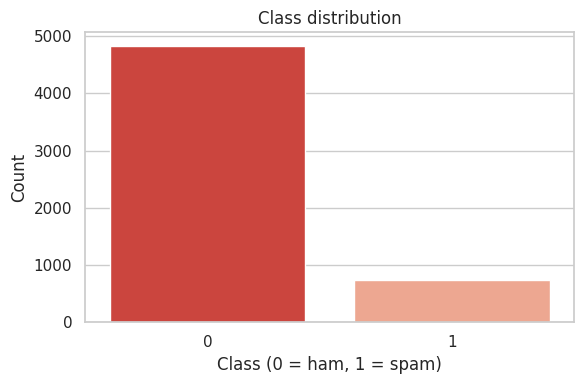

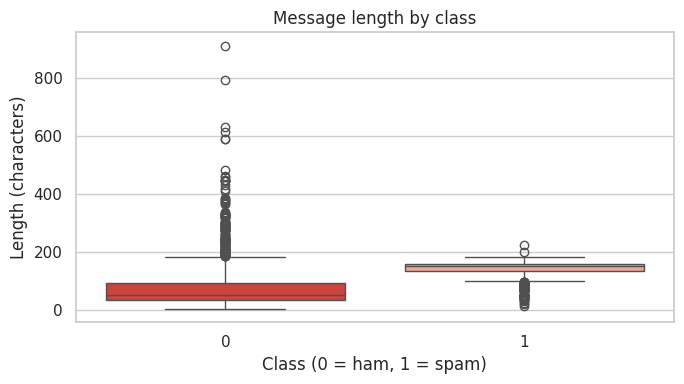

        mean  median
label               
0       72.5    53.0
1      139.7   150.0


In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x="label", data=df, palette="Reds_r", ax=ax)
ax.set(title="Class distribution", xlabel="Class (0 = ham, 1 = spam)", ylabel="Count")
fig.tight_layout(); fig.savefig("figures/class_distribution.png", dpi=FIG_DPI); plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(x="label", y="text_length", data=df, palette="Reds_r", ax=ax)
ax.set(title="Message length by class", xlabel="Class (0 = ham, 1 = spam)", ylabel="Length (characters)")
fig.tight_layout(); fig.savefig("figures/text_length_boxplot.png", dpi=FIG_DPI); plt.show()

print(df.groupby("label")["text_length"].agg(["mean", "median"]).round(1))

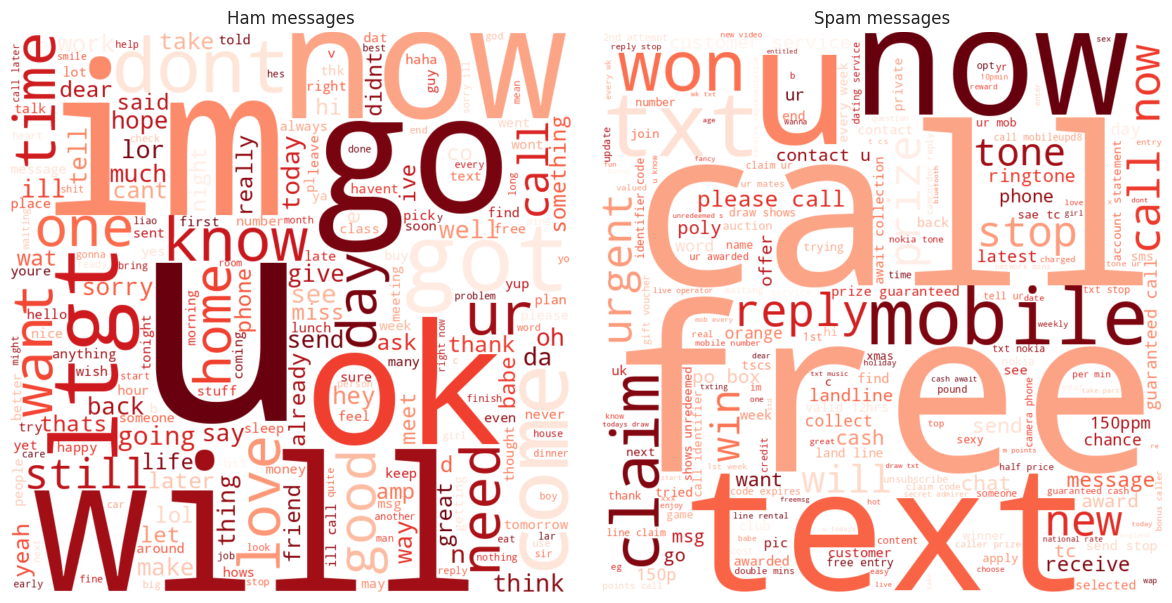

In [4]:
ham_text = " ".join(df.loc[df["label"] == 0, "text"])
spam_text = " ".join(df.loc[df["label"] == 1, "text"])
wc_kwargs = dict(width=800, height=800, background_color="white", colormap="Reds_r")

fig, axs = plt.subplots(1, 2, figsize=(12, 6))
for ax, txt, title in zip(axs, [ham_text, spam_text], ["Ham messages", "Spam messages"]):
    ax.imshow(WordCloud(**wc_kwargs).generate(txt), interpolation="bilinear")
    ax.set_title(title); ax.axis("off")
fig.tight_layout(); fig.savefig("figures/wordclouds.png", dpi=FIG_DPI); plt.show()

## 2. Train / test split and models

Stratified 80/20 split. TF-IDF (unigrams + bigrams, 1000 features) lives inside a `Pipeline`,
so the vocabulary and IDF weights are learned **from the training set only**.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    df["text"], df["label"], test_size=0.2, random_state=SEED, stratify=df["label"])
print(f"train: {len(X_train)}  test: {len(X_test)}  (spam in test: {int(y_test.sum())})")

def make_models():
    clfs = {
        "Naive Bayes": MultinomialNB(alpha=0.1),
        "Logistic Regression": LogisticRegression(max_iter=1000),
        "SVM": SVC(kernel="linear"),
        "Random Forest": RandomForestClassifier(n_estimators=100, random_state=SEED),
    }
    return {name: Pipeline([("tfidf", TfidfVectorizer(max_features=1000, ngram_range=(1, 2))),
                            ("clf", clf)]) for name, clf in clfs.items()}

def spam_score(model, texts):
    """Continuous spam score for ROC-AUC."""
    return model.predict_proba(texts)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(texts)

def evaluate(model, texts, y):
    pred = model.predict(texts)
    return {"Accuracy": accuracy_score(y, pred), "Precision": precision_score(y, pred),
            "Recall": recall_score(y, pred), "F1": f1_score(y, pred),
            "ROC-AUC": roc_auc_score(y, spam_score(model, texts))}

models = make_models()
for name, m in models.items():
    m.fit(X_train, y_train)

clean = pd.DataFrame({n: evaluate(m, X_test, y_test) for n, m in models.items()}).T
clean.index.name = "Model"
clean.round(3)

train: 4459  test: 1115  (spam in test: 149)


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Naive Bayes,0.976,0.969,0.846,0.903,0.984
Logistic Regression,0.978,1.000,0.839,0.912,0.990
SVM,0.985,0.985,0.899,0.940,0.990
Random Forest,0.982,0.985,0.879,0.929,0.988


### Confusion matrices and ROC curves

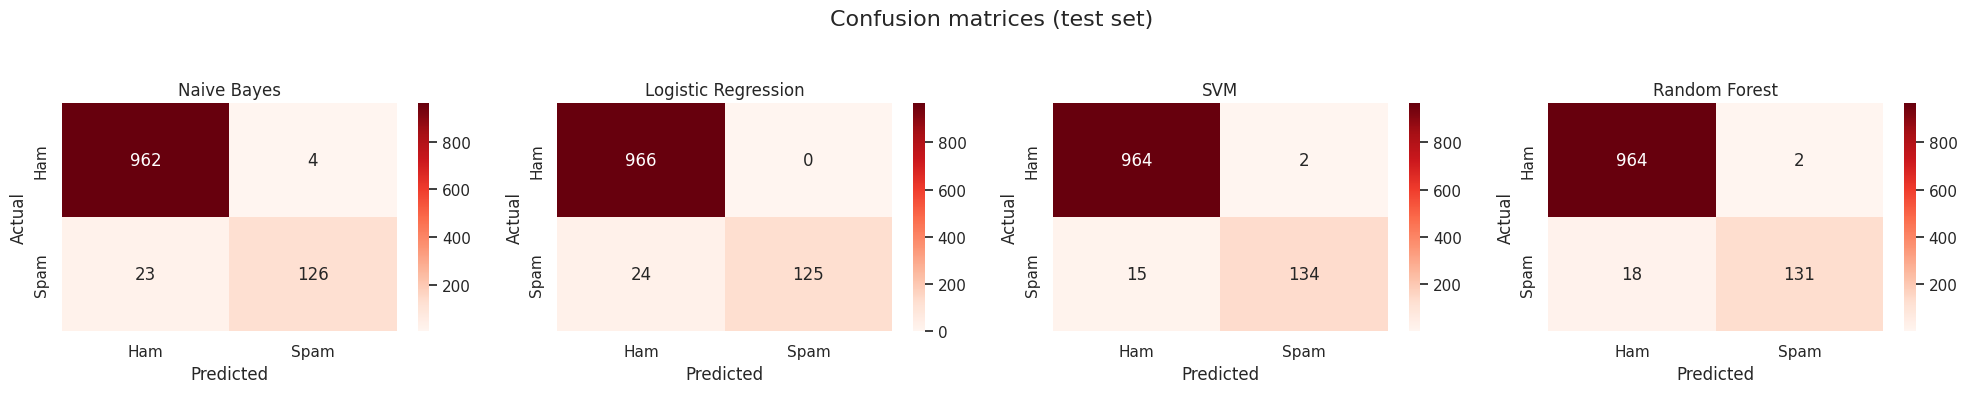

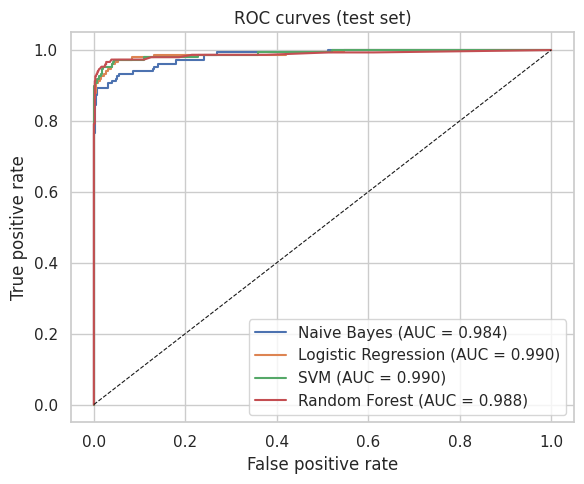

In [6]:
conf = {n: confusion_matrix(y_test, m.predict(X_test)) for n, m in models.items()}

fig, axs = plt.subplots(1, 4, figsize=(20, 4))
for ax, (name, cm) in zip(axs, conf.items()):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Reds", xticklabels=["Ham", "Spam"],
                yticklabels=["Ham", "Spam"], ax=ax)
    ax.set(title=name, xlabel="Predicted", ylabel="Actual")
fig.suptitle("Confusion matrices (test set)", fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.94]); fig.savefig("figures/confusion_matrices.png", dpi=FIG_DPI); plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
for name, m in models.items():
    fpr, tpr, _ = roc_curve(y_test, spam_score(m, X_test))
    ax.plot(fpr, tpr, label=f"{name} (AUC = {clean.loc[name, 'ROC-AUC']:.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=0.8)
ax.set(title="ROC curves (test set)", xlabel="False positive rate", ylabel="True positive rate")
ax.legend(loc="lower right"); fig.tight_layout(); fig.savefig("figures/roc_curves.png", dpi=FIG_DPI); plt.show()

## 3. Adversarial test: character-level obfuscation

Spam messages in the **test set** have letters replaced by look-alike symbols with probability `ADV_PROB`
(e.g. `free → fr33`, `call → c@ll`). Models are **not** retrained. Because the perturbation is random,
it is repeated `N_ADV_RUNS` times with different seeds and the mean ± std is reported.

In [7]:
ADV_MAP = {"a": ["@", "4"], "e": ["3"], "i": ["1", "!"], "o": ["0"], "s": ["$", "5"],
           "l": ["1"], "t": ["7"], "c": ["(", "<"], "u": ["v"], "b": ["8"]}

def obfuscate(text, rng, prob=ADV_PROB):
    return "".join(rng.choice(ADV_MAP[c]) if c in ADV_MAP and rng.random() < prob else c for c in text)

def attack_test_set(seed):
    rng = random.Random(seed)
    return pd.Series([obfuscate(t, rng) if y == 1 else t for t, y in zip(X_test, y_test)], index=X_test.index)

runs = {n: [] for n in models}
for run in range(N_ADV_RUNS):
    X_adv = attack_test_set(SEED + run)
    for name, m in models.items():
        runs[name].append(evaluate(m, X_adv, y_test))

adv_mean = pd.DataFrame({n: pd.DataFrame(r).mean() for n, r in runs.items()}).T
adv_std = pd.DataFrame({n: pd.DataFrame(r).std() for n, r in runs.items()}).T
adv_mean.index.name = adv_std.index.name = "Model"

metrics = ["Accuracy", "Precision", "Recall", "F1"]
drop = (clean[metrics] - adv_mean[metrics])
print("Example of an obfuscated spam message:")
print("  before:", X_test[y_test == 1].iloc[0]); print("  after: ", attack_test_set(SEED)[y_test == 1].iloc[0])
print(f"\nMean over {N_ADV_RUNS} runs (adversarial):"); display(adv_mean[metrics].round(3))
print("Drop vs clean (absolute, percentage points x100):"); display((drop * 100).round(1))

Example of an obfuscated spam message:
  before: get ur 1st ringtone free now reply to this msg with tone gr8 top 20 tones to your phone every week just 150 per wk 2 opt out send stop 08452810071 16

  after:  ge7 vr 1st ring70n3 free now reply 7o 7hi5 m5g w!th tone gr8 top 20 tones to y0ur phone every week jv5t 150 per wk 2 0pt 0ut send stop 08452810071 16


Mean over 20 runs (adversarial):


,Accuracy,Precision,Recall,F1
Model,,,,
Naive Bayes,0.961,0.965,0.733,0.832
Logistic Regression,0.923,1.000,0.423,0.594
SVM,0.950,0.979,0.640,0.774
Random Forest,0.924,0.970,0.442,0.607


Drop vs clean (absolute, percentage points x100):


,Accuracy,Precision,Recall,F1
Model,,,,
Naive Bayes,1.5,0.5,11.3,7.1
Logistic Regression,5.6,0.0,41.6,31.9
SVM,3.5,0.6,25.9,16.7
Random Forest,5.8,1.5,43.8,32.2


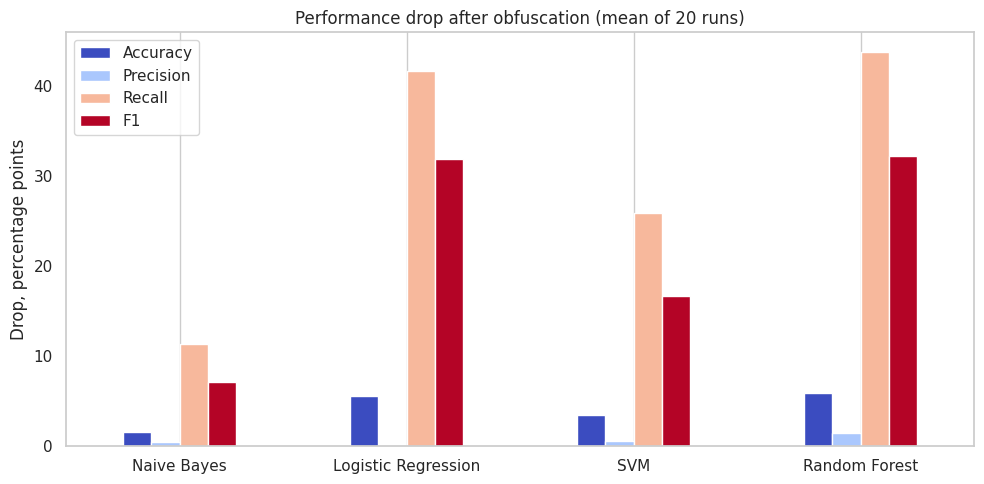

In [8]:
ax = (drop * 100).plot(kind="bar", figsize=(10, 5), colormap="coolwarm", rot=0)
ax.set(title=f"Performance drop after obfuscation (mean of {N_ADV_RUNS} runs)",
       ylabel="Drop, percentage points", xlabel="")
ax.grid(axis="y"); plt.tight_layout(); plt.savefig("figures/adversarial_drop.png", dpi=FIG_DPI); plt.show()

## 4. Sensitivity check: duplicate messages

The dataset contains exact duplicate messages, which can end up on both sides of the split.
The same pipeline is re-run after dropping duplicates.

In [9]:
dd = df.drop_duplicates(subset="text_raw")
Xtr, Xte, ytr, yte = train_test_split(dd["text"], dd["label"], test_size=0.2, random_state=SEED, stratify=dd["label"])
dedup = {}
for name, m in make_models().items():
    m.fit(Xtr, ytr); dedup[name] = evaluate(m, Xte, yte)
dedup = pd.DataFrame(dedup).T; dedup.index.name = "Model"
print(f"after dropping duplicates: {len(dd)} messages")
dedup.round(3)

after dropping duplicates: 5171 messages


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Naive Bayes,0.972,0.964,0.809,0.880,0.985
Logistic Regression,0.965,0.961,0.756,0.846,0.981
SVM,0.979,0.950,0.878,0.913,0.987
Random Forest,0.980,0.991,0.847,0.914,0.978


## 5. Save results and models

In [10]:
clean.round(4).to_csv("results/metrics_clean.csv")
adv_mean.round(4).to_csv("results/metrics_adversarial_mean.csv")
adv_std.round(4).to_csv("results/metrics_adversarial_std.csv")
dedup.round(4).to_csv("results/metrics_deduplicated.csv")
json.dump({n: cm.tolist() for n, cm in conf.items()}, open("results/confusion_matrices.json", "w"), indent=2)
for name, m in models.items():
    joblib.dump(m, f"models/{name.lower().replace(' ', '_')}.joblib")   # models/ is git-ignored
print("saved to results/ and models/")

saved to results/ and models/
